# 03 Exploratory analysis

## Read me first — what this dataset is, and what it is not

The Arcep `e-3.csv` snapshot for Troyes Champagne Métropole is a **mature-rollout** snapshot. By the time the file was published, almost every PM (mutualisation point) in the metropolis had been deployed. That has three consequences for the analysis below — important to flag up front so the reader doesn't mistake them for analytical errors:

1. **`pm_etat` is essentially constant.** Only ~0.01% of PMs are not yet `deploye`. We initially defined the lag target on `pm_etat`, found there was no signal to model, and pivoted to `imb_etat` (the *building-level* service state). The variation lives there.
2. **`date_completude` is 100% null** in this snapshot. That kills any temporal recency analysis on this file. The notebook keeps a guarded check so a future quarterly drop with populated dates surfaces immediately.
3. **The market has 2 operators with HHI ≈ 0.54** at the metropolis level, but the per-commune HHI is ≈ 1 because each commune is single-operator (RIP zoning). So 'operator competition' has no per-commune variance and was dropped from the equity index.

These are properties of the data, not the analysis. Calling them out is itself part of the work.

In [1]:
import sys, os
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))
%load_ext autoreload
%autoreload 2

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from ftth_equity import config, io
df = io.load_parquet(config.INTERIM / 'buildings_clean.parquet')
df.shape

(57072, 23)

## Headline numbers

`lagging_share` ≈ 0.057 means about 5.7% of buildings have an `imb_etat` other than `deploye` (states like `cible`, `signe`, `en cours de deploiement`, `raccordable demande`, `abandonne`). That's the population the rest of the analysis is about.

In [3]:
headline = {
  'n_buildings': int(len(df)),
  'n_communes': int(df['code_insee'].nunique()),
  'n_pm': int(df['pm_ref'].nunique()),
  'n_operators': int(df['code_l331'].nunique()),
  'lagging_share': float(df['is_lagging'].mean()),
  'imb_deploye_share': float((df['imb_etat'].astype(str) == 'deploye').mean()),
  'pm_deploye_share': float((df['pm_etat'].astype(str) == 'deploye').mean()),
}
(config.REPORTS / 'figures').mkdir(parents=True, exist_ok=True)
(config.REPORTS / 'figures' / 'headline.json').write_text(json.dumps(headline, indent=2))
pd.DataFrame([headline]).T.rename(columns={0: 'value'})

,value
n_buildings,57072.000000
n_communes,81.000000
n_pm,281.000000
n_operators,2.000000
lagging_share,0.056543
imb_deploye_share,0.943457
pm_deploye_share,0.999860


## Null rates per column

`date_completude` and `date_completude_manquante` are 100% null — together they confirm the no-temporal-data point. `batiment` and `cp_no_voie` are mostly null too; we treat 'has a building label / address number' as a binary feature in the model rather than trying to use the value.

In [4]:
null_tbl = (df.isna().mean().sort_values(ascending=False) * 100).round(1)
null_tbl = null_tbl.to_frame('pct_null').query('pct_null > 0')
null_tbl

,pct_null
date_completude_manquante,100.0
date_completude,100.0
batiment,95.3
cp_no_voie,89.9
type_voie,2.7
catg_loc_imb,2.3


## Building-state distribution

This is where the variation actually sits. `cible` (target), `signe` (contracted), `en cours de deploiement`, `raccordable demande` and `abandonne` together make up the lagging population. They are not all the same thing — `abandonne` is a hard 'no', `cible` is 'planned, not yet started' — but for a binary classifier they behave similarly enough.

In [5]:
imb = df['imb_etat'].astype(str).value_counts(dropna=False).rename_axis('imb_etat').reset_index(name='n')
imb['pct'] = (imb['n'] / imb['n'].sum() * 100).round(2)
imb

,imb_etat,n,pct
0,deploye,53845,94.35
1,cible,2458,4.31
2,signe,558,0.98
3,en cours de deploiement,71,0.12
4,abandonne,65,0.11
5,raccordable demande,55,0.10
6,NaN,20,0.04


## Building-state vs lagging target — sanity check

Every row with `imb_etat != 'deploye'` should map to `is_lagging = 1`. If the cross-tab off-diagonal is non-zero, the target definition has a bug.

In [6]:
pd.crosstab(df['imb_etat'].astype(str), df['is_lagging'], margins=True)

is_lagging,0,1,All
imb_etat,,,
abandonne,0,65,65
cible,0,2458,2458
deploye,53845,0,53845
en cours de deploiement,0,71,71
raccordable demande,0,55,55
signe,0,558,558
All,53845,3207,57052


## Building-category mix and lag rate per category

Collective dwellings (`entre 2 et 11`) lag at roughly 3× the rate of detached homes (`individuel`). That's the strongest single feature in the model — connecting a multi-dwelling building involves landlord agreements and shared-infrastructure work that single-family homes don't need.

In [7]:
cat = (
    df.groupby(df['catg_loc_imb'].astype(str))
      .agg(n=('imb_id', 'count'), lag_share=('is_lagging', 'mean'))
      .sort_values('n', ascending=False)
)
cat['lag_pct'] = (cat['lag_share'] * 100).round(2)
cat[['n', 'lag_pct']]

,n,lag_pct
catg_loc_imb,,
individuel,49103,4.46
entre 2 et 11,6645,13.17


## Top 15 communes by lag rate

Filtered to communes with at least 100 buildings so a single odd address can't dominate the ranking. The bottom of the distribution is uninformative — most small communes are 100% deployed and would all show 0% — so I sort descending and only show the head.

In [8]:
com = (
    df.groupby('nom_com')
      .agg(n=('imb_id', 'count'), lag_share=('is_lagging', 'mean'))
      .query('n >= 100')
      .assign(lag_pct=lambda d: (d['lag_share'] * 100).round(1))
      .drop(columns='lag_share')
      .sort_values('lag_pct', ascending=False)
)
n_zero = int((com['lag_pct'] == 0).sum())
print(f'communes with >=100 buildings: {len(com)} — of which {n_zero} are 0% lag')
com.head(15)

communes with >=100 buildings: 70 — of which 14 are 0% lag


,n,lag_pct
nom_com,,
Rouilly-Saint-Loup,293,24.6
Saint-BenoÃ®t-sur-Seine,282,20.9
Mergey,379,16.4
Feuges,160,15.0
BrÃ©viandes,1445,11.5
Macey,483,10.8
Fontvannes,314,10.8
BuchÃ¨res,875,10.4
Fresnoy-le-ChÃ¢teau,145,9.0


## Lag rate by commune — top 15 (bar chart)

Earlier versions of this chart sorted by commune *size* and produced an almost-flat plot — Troyes itself is large but well-served, so its bar dwarfed every other communal lag rate. Sorting by lag rate (and clipping to the top 15) shows the actual story: a handful of small-to-medium communes carry most of the deficit.

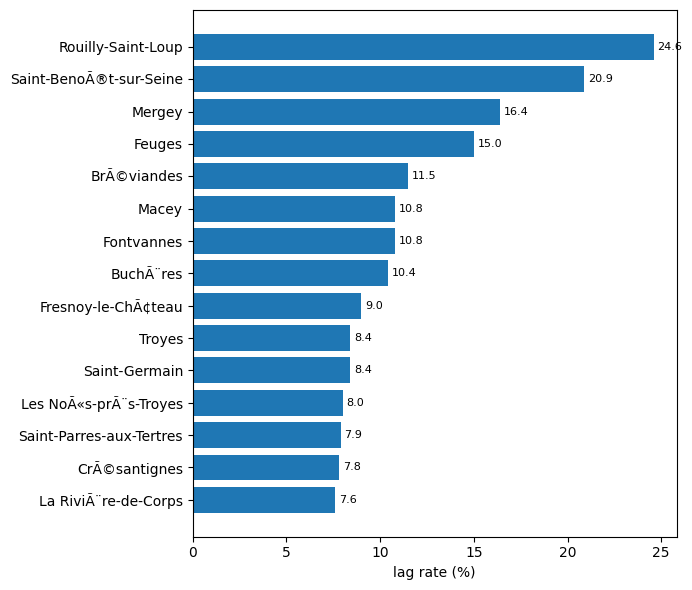

In [9]:
top = com.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top.index, top['lag_pct'])
ax.set_xlabel('lag rate (%)'); ax.set_ylabel('')
for i, v in enumerate(top['lag_pct']):
    ax.text(v + 0.2, i, f'{v:.1f}', va='center', fontsize=8)
fig.tight_layout()
fig.savefig(config.FIGURES / 'lagging_by_commune.png', dpi=140)

## Lag rate distribution across communes

Histogram of per-commune lag rates (filtered to ≥50 buildings). The shape — heavy mass at 0%, a long tail toward 25% — is what makes this an equity question rather than a forecasting question. The metropolis is mostly fine; a minority of communes carry the deficit.

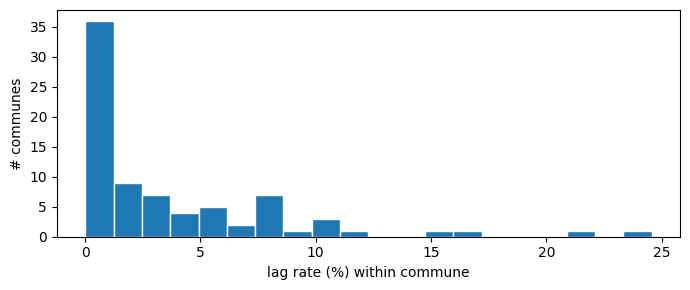

In [10]:
lag_per_com = (
    df.groupby('nom_com')
      .agg(n=('imb_id', 'count'), lag=('is_lagging', 'mean'))
      .query('n >= 50')['lag']
)
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(lag_per_com * 100, bins=20, edgecolor='white')
ax.set_xlabel('lag rate (%) within commune'); ax.set_ylabel('# communes')
fig.tight_layout()
fig.savefig(config.FIGURES / 'lag_distribution.png', dpi=140)

## Completion-date timeline — guarded check

`date_completude` is 100% null on this snapshot, so the temporal dimension is not available here. The cell is left in so a future quarterly drop with populated dates produces a chart automatically rather than failing silently.

In [11]:
date_pct_null = df['date_completude'].isna().mean() * 100
print(f'date_completude is {date_pct_null:.1f}% null')
s = pd.to_datetime(df['date_completude'], errors='coerce').dropna()
if len(s):
    monthly = s.dt.to_period('M').value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(8, 3))
    monthly.plot(ax=ax)
    ax.set_xlabel('month'); ax.set_ylabel('completed buildings')
    fig.tight_layout()
    fig.savefig(config.FIGURES / 'completion_timeline.png', dpi=140)
    monthly.tail(12)
else:
    print('no completion dates available — temporal analysis skipped on this snapshot')

date_completude is 100.0% null
no completion dates available — temporal analysis skipped on this snapshot
